In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version('2.6.0')

In [3]:
if torch.cuda.is_available():
    device= "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device="cpu"
    

In [4]:
import matplotlib.pyplot as plt

plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc('ytick', labelsize=10)

Convolutional Layers

Implementing Convolutional Layers with PyTorch

Let's load two sample images and convert them to a float tensor:

In [5]:
import  numpy as np
import torch
from sklearn.datasets import load_sample_images

sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

In [6]:
sample_images.shape


torch.Size([2, 427, 640, 3])

Let's Permute the dimensions from [batch, height, width, channels] to [batch, channels, height, width], as PyTorch expects:

In [7]:
sample_images_permuted = sample_images.permute(0, 3, 1,2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

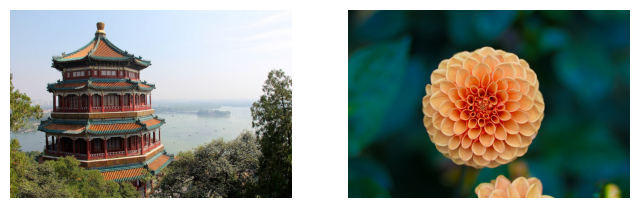

In [8]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

Now let's rescale the pixel values from 0-255 to 0-1, and center crop them to small 70x120 images:

In [9]:
import torchvision
import torchvision.transforms.v2 as T

cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

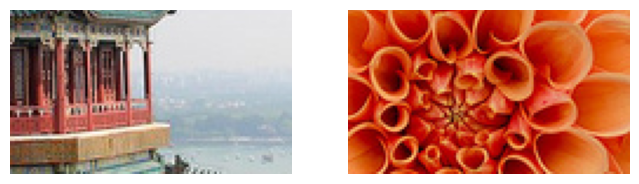

In [10]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2,1)
plot_image(cropped_images[0])
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [11]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
fmaps = conv_layer(cropped_images)

In [12]:
fmaps.shape

torch.Size([2, 32, 64, 114])

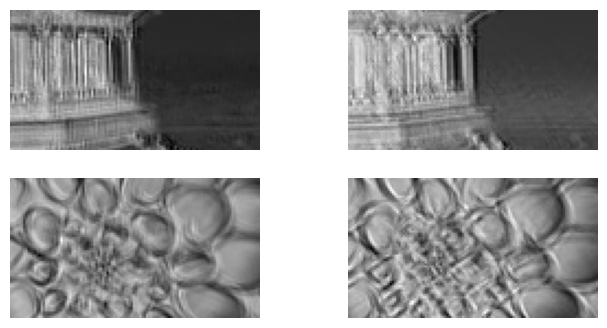

In [13]:
plt.figure(figsize=(8, 4))
for image_idx in(0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap="gray")
        plt.axis("off")

plt.show()

As you can see, randomly generated filters typically act like edge detectors, whichis great since that's a useful tool in image processing, and that's the type of filters that a convolutional layer typically starts with. Then, during training, it gradually learns improved filters to recognize useful patterns for the task.

Now let's use Zero-Padding:

In [14]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7,
                       padding="same")
fmaps = conv_layer(cropped_images)

In [15]:
fmaps.shape

torch.Size([2, 32, 70, 120])

In [16]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2,
                       padding=3)
fmaps  = conv_layer(cropped_images)
fmaps.shape

torch.Size([2, 32, 35, 60])

Let's now look at the shape of the parameters:

In [17]:
conv_layer.weight.shape

torch.Size([32, 3, 7, 7])

In [18]:
conv_layer.bias.shape

torch.Size([32])

In [19]:
import torch.nn.functional as F

torch.manual_seed(42)
filters = torch.randn([2, 3, 7, 7])
biases = torch.zeros([2])
fmaps  = F.conv2d(cropped_images, filters, biases, stride=1, padding='same')

In [20]:
fmaps.shape

torch.Size([2, 2, 70, 120])

Let's manually create two filters full of zeros, except for a veticall line of 1s in the first filter, and a horizontal one in the second filter. The two output feature maps highlight vertical lines and horizontal lines, respectively. In practic you will probably never need to create filters manually, since the convolutional layers will learn them automatically

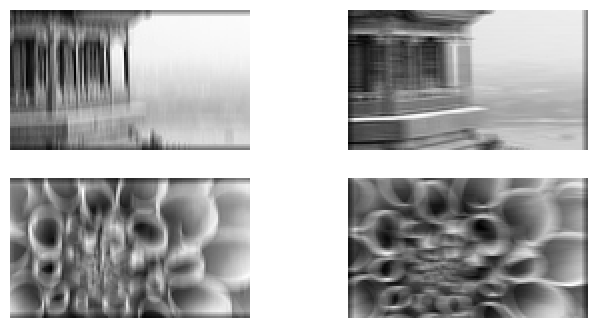

In [21]:
plt.figure(figsize=(8, 4))
filters = torch.zeros([2, 3, 7,7])
filters[0, :, :, 3] = 1
filters[1, :, 3, :] = 1
fmaps = F.conv2d(cropped_images, filters, biases, stride=1, padding="same")

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

Pooling Layers

Implementing Pooling layers with PyTorch

Mas Pooling

In [22]:
max_pool = nn.MaxPool2d(kernel_size=2)


In [23]:
output_max = max_pool(cropped_images)

In [24]:
avg_pool = nn.AvgPool2d(kernel_size=2)


In [25]:
output_avg = avg_pool(cropped_images)

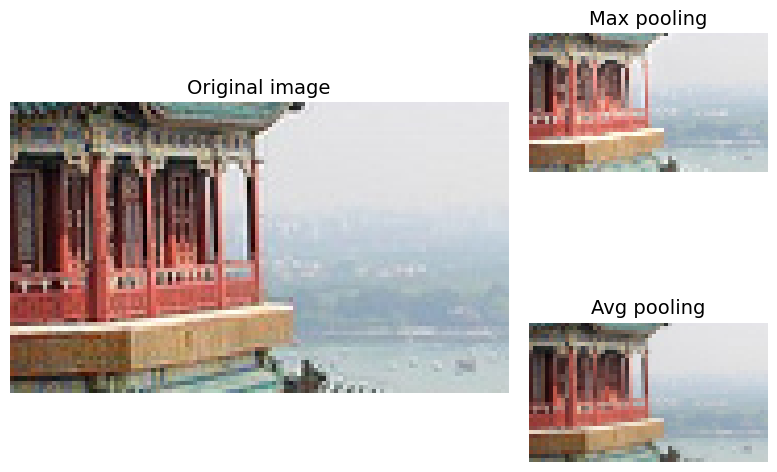

In [26]:
fig = plt.figure(figsize=(8, 6))

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(cropped_images[0].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title("Original image")

ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.imshow(output_max[0].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title("Max pooling")

ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[0].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()

Depth-wise Pooling

In [27]:
import torch.nn.functional as F

class DepthMaxPool2(torch.nn.Module):
    def __init__(self,kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding

    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        Z = inputs.view(batch, channels, height * width)
        Z = Z.permute(0, 2,1)
        Z = F.max_pool1d(Z, kernel_size=self.kernel_size, stride=self.stride,
                         padding=self.padding)
        Z = Z.permute(0, 2, 1)
        return Z.view(batch, -1, height, width)
        

Global Average Pooling

First implementation, not very convenient:

In [28]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))
output = global_avg_pool(cropped_images)

Second implementation(recommended):


In [29]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = cropped_images.mean(dim=(2,3), keepdim=True)

CNN Architectures

Tackling fashion MNIST With a CNN

In [30]:
from functools import partial

torch.manual_seed(42)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")
model = nn.Sequential(
    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),).to(device)

In [31]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader,
          valid_loader, n_epochs):
    history = {"train_losses": [],
               "train_metrics": [],
               "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred  = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item()
        )
        history["train_metrics"].append(metric.compute().item())
        print(f" Epoch {epoch+1}/{n_epochs}",
              f"train loss: {history["train_losses"][-1]:.4f}",
              f"Train metrics : {history["train_metrics"][-1]:.4f}",
              f"valid metric: {history["valid_metrics"][-1]:.4f}")
    return history

In [32]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T. Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data  = torchvision.datasets.FashionMNIST(
    root="datasets", train= False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000]
)

In [33]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)


In [34]:
n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
# history = train(model, optimizer, xentropy, accuracy,
                # train_loader, valid_loader, n_epochs)

Xception

Separable Convolutional Layer

In [35]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride=stride,
            padding=padding, groups=in_channels
        )
        self.pointwise_conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, stride=1, padding=0
        )

    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))
    

Implementing a ResNet-34 CNN Using PyTorch

In [36]:
class ResidualUnit(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        DefaultConv2d = partial(
            nn.Conv2d, kernel_size=3, stride=1, padding=1, bias=False)
        self.main_layers = nn.Sequential(
            DefaultConv2d(in_channels, out_channels, stride=stride),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            DefaultConv2d(out_channels, out_channels),
            nn.BatchNorm2d(out_channels),
        )

        if stride > 1:
            self.skip_connection = nn.Sequential(
                DefaultConv2d(in_channels, out_channels, kernel_size=1,
                              stride=stride, padding=0),
                              nn.BatchNorm2d(out_channels),

            )
        else:
            self.skip_connection = nn.Identity()

    def forward(self, inputs):
        return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

    

In [37]:
class ResNet34(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2,
                      padding=3, bias=False),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        ]
        prev_filters = 64
        for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
            stride = 1 if filters == prev_filters else 2
            layers.append(ResidualUnit(prev_filters, filters, stride=stride))
            prev_filters = filters
        layers += [
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.LazyLinear(10),
        ]
        self.resnet = nn.Sequential(*layers)

    def forward(self,inputs):
        return self.resnet(inputs)

In [38]:
torch.manual_seed(42)
model = ResNet34().to(device)
images = torch.randn(2, 3, 224, 224).to(device)
model(images)

tensor([[ 0.2233, -1.0281,  0.8846,  0.5195,  0.1329, -0.0356,  0.0158,  0.2011,
          1.3775,  0.3885],
        [ 0.2202, -1.0636,  1.1203,  0.5913,  0.0325, -0.1761,  0.0831,  0.0497,
          1.7335,  0.7540]], device='cuda:0', grad_fn=<AddmmBackward0>)

Using torchvision's Pretrained Models

In [39]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

In [40]:
torch.hub.get_dir()

'/home/ziaur/.cache/torch/hub'

In [41]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [46]:
list(torchvision.models.get_model_weights("convnext_base"))

[ConvNeXt_Base_Weights.IMAGENET1K_V1]

In [47]:
transform = weights.transforms()
preprocessed_images = transform(sample_images_permuted)

In [49]:
model.eval()
with torch.no_grad():
    y_logits = model(preprocessed_images.to(device))

y_logits.shape

torch.Size([2, 1000])

In [51]:
y_pred = torch.argmax(y_logits, dim=1)
y_pred

tensor([698, 985], device='cuda:0')

In [52]:
weights.meta.keys()

dict_keys(['min_size', 'categories', 'recipe', '_docs', 'num_params', '_metrics', '_ops', '_file_size'])

In [53]:
class_names = weights.meta["categories"]
[class_names[class_id] for class_id in y_pred]

['palace', 'daisy']

In [54]:
class_names[698]

'palace'

In [55]:
y_top3_logits, y_tope_class_ids = y_logits.topk(k=3, dim=1)
[[class_names[class_id] for class_id in top3] for top3 in y_tope_class_ids]


[['palace', 'monastery', 'lakeside'], ['daisy', 'pot', 'ant']]

In [56]:
y_top3_logits.softmax(dim=1)

tensor([[0.8618, 0.1185, 0.0197],
        [0.8106, 0.0964, 0.0930]], device='cuda:0')

Pretrained Models for Transfer Learning

In [61]:
DefaultFlower102 = partial(torchvision.datasets.Flowers102, root="datasets",
                          transform=weights.transforms(), download=True)
train_set = DefaultFlower102(split="train")
valid_set = DefaultFlower102(split="val")
test_set = DefaultFlower102(split="test")

100%|██████████| 345M/345M [01:03<00:00, 5.41MB/s] 
100%|██████████| 502/502 [00:00<00:00, 765kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 12.2MB/s]


In [62]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

In [63]:
class_names = ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily']

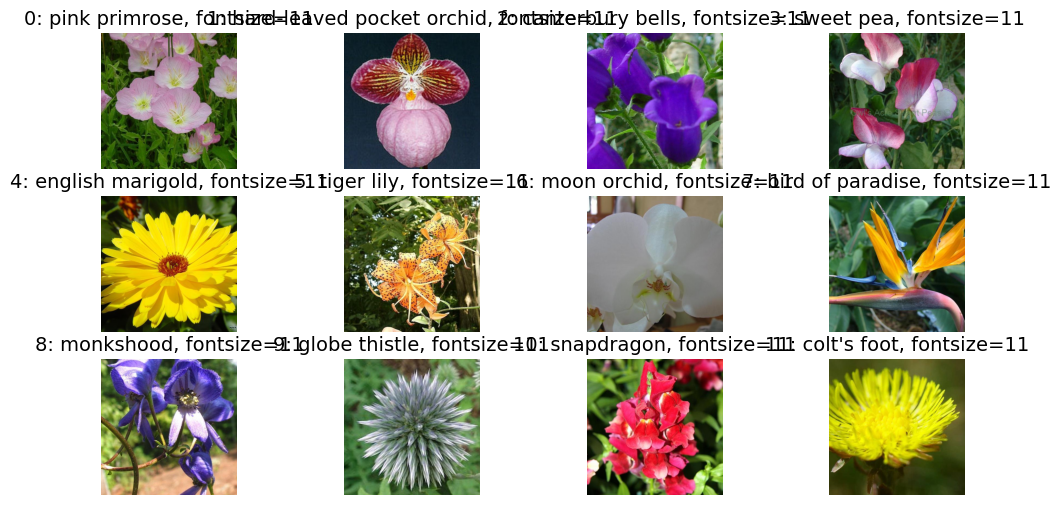

In [65]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])
flowers_to_display = DefaultFlower102(split="train", transform=transform)
sample_flowers = sorted({y: img for img, y in flowers_to_display}.items())[:12]

plt.figure(figsize=(12, 6))
for class_id, image in sample_flowers:
    if class_id == 12:break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}, fontsize=11")

plt.show()

In [67]:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [68]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [69]:
n_classes = 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

In [70]:
for param in model.parameters():
    param.requires_grad= False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=102).to(device)
# history = train(model, optimizer, xentropy, accuracy,
                # train_loader, valid_loader, n_epochs)

 Epoch 1/5 train loss: 2.2947 Train metrics : 0.8167 valid metric: 0.8167
 Epoch 2/5 train loss: 1.4601 Train metrics : 0.8363 valid metric: 0.8363
 Epoch 3/5 train loss: 1.0018 Train metrics : 0.8755 valid metric: 0.8755
 Epoch 4/5 train loss: 0.7223 Train metrics : 0.8784 valid metric: 0.8784
 Epoch 5/5 train loss: 0.5317 Train metrics : 0.8833 valid metric: 0.8833


In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
                # train_loader, valid_loader, n_epochs)

 Epoch 1/5 train loss: 0.4064 Train metrics : 0.8961 valid metric: 0.8961
 Epoch 2/5 train loss: 0.3053 Train metrics : 0.8922 valid metric: 0.8922
 Epoch 3/5 train loss: 0.2415 Train metrics : 0.8902 valid metric: 0.8902
 Epoch 4/5 train loss: 0.2198 Train metrics : 0.8990 valid metric: 0.8990
 Epoch 5/5 train loss: 0.1726 Train metrics : 0.8951 valid metric: 0.8951


In [75]:
for param in model.parameters():
    param.requires_grad = True

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
                # train_loader, valid_loader, n_epochs)

In [77]:
import torchvision.transforms.v2 as T

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, .225]),
])

Classification and Localization

In [82]:
class FlowerLocator(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.localization_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_model.classifier[2].in_features, 4)
        )

    def forward(self, X):
        features = self.base_model.features(X)
        pool = self.base_model.avgpool(features)
        y_pred_logits = self.base_model.classifier(pool)
        y_pred_bbox = self.localization_head(pool)
        return y_pred_logits, y_pred_bbox

torch.manual_seed(42)
locator_model = FlowerLocator(model).to(device)

Once the model is trained, we can use it to classify and locate the main flower in each image like this:

In [83]:
prepoc_images = torch.randn(2, 3, 224, 224)
y_pred_logits, y_pred_bbox = locator_model(preprocessed_images.to(device))

In [92]:
import torchvision.tv_tensors

bbox = torchvision.tv_tensors.BoundingBoxes(
    [[377, 199, 248, 262]],
    format="CXCYWH",
    canvas_size=(500, 754)
)

In [93]:
transform(bbox)

BoundingBoxes([[123,  90, 123, 156]], format=BoundingBoxFormat.CXCYWH, canvas_size=(224, 224), clamping_mode=soft)

The API also supports nested data structures, and it transforms the images and bounding boxes it finds:

In [94]:
torch.manual_seed(42)

first_image = torchvision.datasets.Flowers102(root="datasets",split="train")[0][0]

prepoc_image, preproc_target = transform(
    (first_image, {"label": 0, "bbox": bbox})
)
preproc_bbox = preproc_target["bbox"]

Here's how to draw boounding boxes:

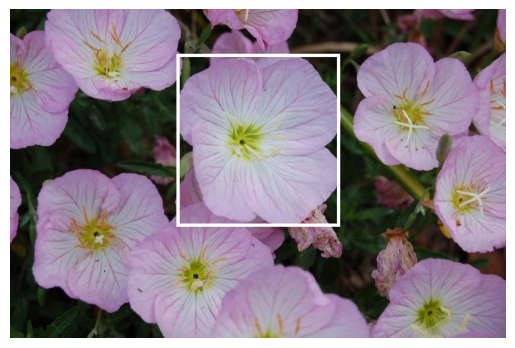

In [95]:
def get_image_with_bbox(image, bbox, width=5, color="white"):
    bbox_xyxy = torchvision.ops.box_convert(bbox, "cxcywh", "xyxy")
    return torchvision.utils.draw_bounding_boxes(
        image, bbox_xyxy, width=width, colors=color
    )

first_image_ts = T.ToImage()(first_image)
image_with_bbox = get_image_with_bbox(first_image_ts, bbox)
plot_image(image_with_bbox)
plt.show()

Let's look at the transformed image and bounding box:

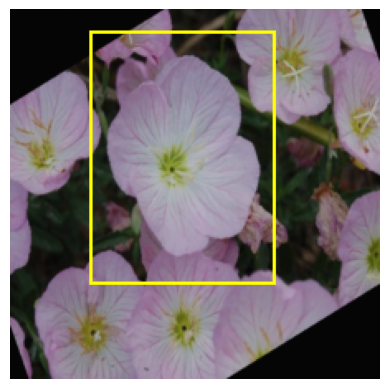

In [98]:
def denormalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    return (image * torch.tensor(std).view(-1, 1, 1)
            + torch.tensor(mean).view(-1, 1, 1))

image_with_bbox2 = get_image_with_bbox(
    denormalize(prepoc_image), preproc_bbox, width=2, color="yellow")
plot_image(image_with_bbox2)
plt.show()

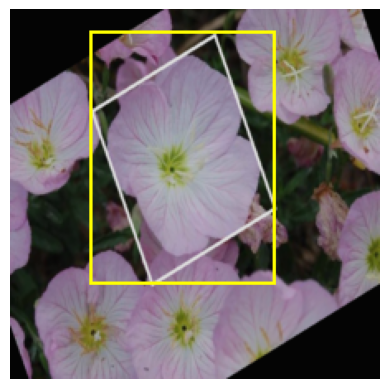

In [102]:
torch.manual_seed(42)

preproc_image2, preproc_target2 = transform(
    (image_with_bbox, {"label": 0, "bbox": bbox})
)
image_and_bbox3 = get_image_with_bbox(
    denormalize(preproc_image2), preproc_target2["bbox"], width=2, color="yellow")
plot_image(image_and_bbox3)

In [103]:
from ultralytics import YOLO

model = YOLO('yolov9m.pt')
images = ["https://homl.info/soccer.jpg", "https://homl.info/traffic.jpg"]
results = model(images)


0: 640x640 5 persons, 2 sports balls, 868.7ms
1: 640x640 3 persons, 7 cars, 1 motorcycle, 11 trucks, 868.7ms
Speed: 20.3ms preprocess, 868.7ms inference, 21.9ms postprocess per image at shape (1, 3, 640, 640)


In [104]:
results[0].to_df()

name,class,confidence,box
str,i64,f64,struct[4]
"""sports ball""",32,0.96214,"{245.35733,286.03003,300.62509,343.57184}"
"""person""",0,0.93886,"{380.47516,52.46332,548.28998,408.30408}"
"""person""",0,0.93407,"{234.47823,31.53574,365.06073,400.27792}"
"""person""",0,0.93391,"{85.80923,19.24835,247.10776,406.453}"
"""person""",0,0.82737,"{41.21785,74.47363,175.22493,399.32819}"
"""person""",0,0.40399,"{613.49731,372.65881,639.71973,419.1228}"
"""sports ball""",32,0.33764,"{23.80591,337.59879,46.33569,346.89529}"


In [105]:
results[0].summary()[0]

{'name': 'sports ball',
 'class': 32,
 'confidence': 0.96214,
 'box': {'x1': 245.35733, 'y1': 286.03003, 'x2': 300.62509, 'y2': 343.57184}}

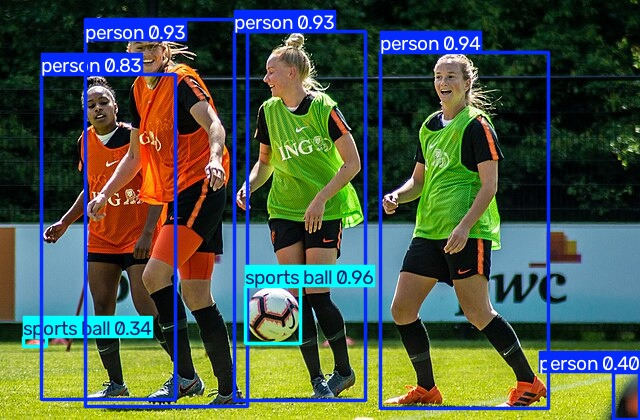

In [106]:
import PIL

results[0].save("my_annotated_soccer.jpg")
PIL.Image.open("my_annotated_soccer.jpg")

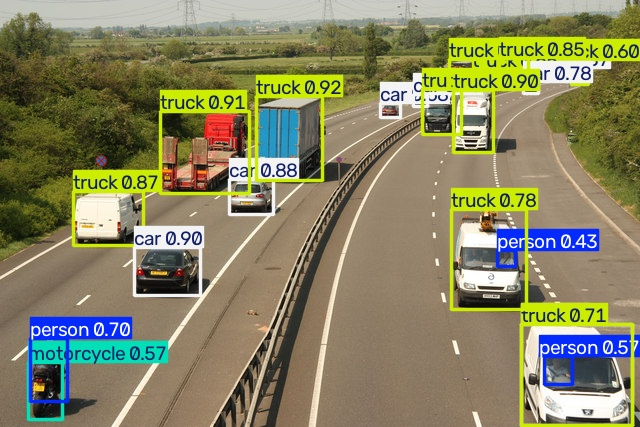

In [107]:
results[1].save("my_annotated_traffic.jpg")
PIL.Image.open("my_annotated_traffic.jpg")

Object Tracking


In [108]:
my_video = "https://homl.info/cars.mp4"
results = model.track(source=my_video, stream=True, save=True)
for frame_results in results:
    summary = frame_results.summary()
    track_ids = [obj["track_id"] for obj in summary]
    print("Track ids:", track_ids)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.7 MB ? eta -:--:--
   ━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.7 MB ? eta -:--:--
   ━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.7 MB ? eta -:--:--
   ━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.7 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 0.8/1.7 MB 896.6 kB/s eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━ 1.3/1.7 MB 1.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.5 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 3.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


video 1/1 (frame 1/243) /home/ziaur/ziazh/daniel bourke 1/cars.mp4: 384x640 7 cars, 553.0ms
Track ids: [1, 2, 3, 4, 5, 6, 7]
video 1/1 (frame 2/243) /home/ziaur/ziazh/daniel bourke 1/cars.mp4: 384x640 7 cars, 469.9ms
Track ids: [1, 2, 3, 4, 5, 6, 7]
video 1/1 (frame 3/243) /h

Semantic Segmentation


In [109]:
from pathlib import Path
import urllib.request

def download_file(url, path):
    path = Path(path)
    if not path.is_file():
        path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(url, path)

download_file("https://homl.info/soccer.jpg", "datasets/images/soccer.jpg")

In [113]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

weights  = FCN_ResNet50_Weights.DEFAULT
model = fcn_resnet50(weights=weights)
model.eval()

img = PIL.Image.open("datasets/images/soccer.jpg")
transform = weights.transforms()
batch = transform(img).unsqueeze(0)

with torch.no_grad():
    masks  = model(batch)["out"].softmax(dim=1)

class_names = weights.meta["categories"]
name_to_id = {name: class_id for class_id, name in enumerate(class_names)}
mask = masks[0, name_to_id["person"]]

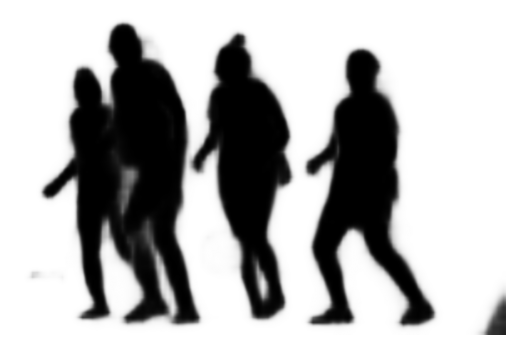

In [114]:
plt.imshow(mask, cmap="binary")
plt.axis("off")
plt.show()

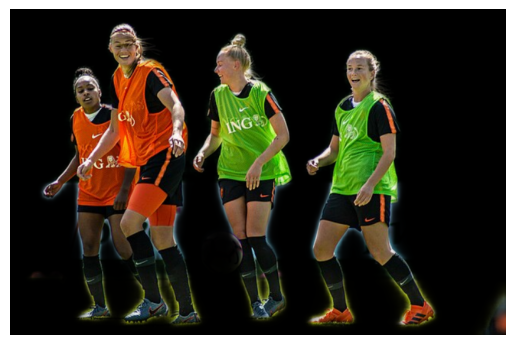

In [115]:
masked_image = mask.unsqueeze(0) * denormalize(batch.squeeze(0))
plot_image(masked_image)

Extra Material - How mAP Relates to Precision/Recall

In [116]:
def maximum_precisions(precisions):
    return np.flip(np.maximum.accumulate(np.flip(precisions)))

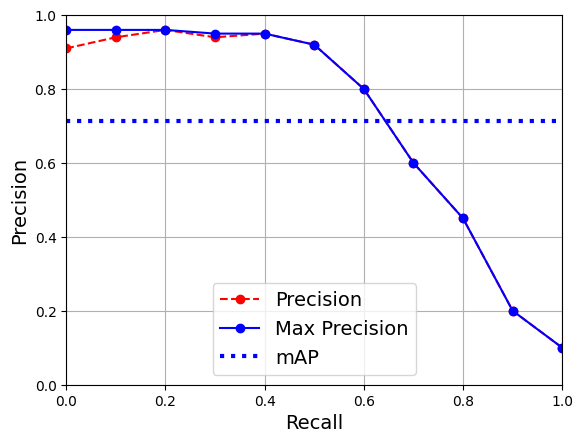

In [117]:
import numpy as np

recalls = np.linspace(0, 1, 11)

precisions  = [ 0.91, 0.94, 0.96, 0.94, 0.95, 0.92, 0.80, 0.60, 0.45, 0.20, 0.10]
max_precisions = maximum_precisions(precisions)
mAP = max_precisions.mean()
plt.plot(recalls, precisions, "ro--", label="Precision")
plt.plot(recalls, max_precisions, "bo-", label="Max Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0,1], [mAP, mAP], "b:", linewidth=3, label="mAP")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower center")
plt.show()